In [1]:
import pandas as pd
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.set_index('Order Date', inplace=True)
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2016-11-08,2,CA-2016-152156,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2016-06-12,3,CA-2016-138688,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2015-10-11,4,US-2015-108966,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2015-10-11,5,US-2015-108966,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
monthly_sales = df['Sales'].resample('M').sum()
monthly_sales

/tmp/ipykernel_18181/964162107.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Sales'].resample('M').sum()


,Sales
Order Date,
2014-01-31,14236.8950
2014-02-28,4519.8920
2014-03-31,55691.0090
2014-04-30,28295.3450
2014-05-31,23648.2870
2014-06-30,34595.1276
2014-07-31,33946.3930
2014-08-31,27909.4685
2014-09-30,81777.3508


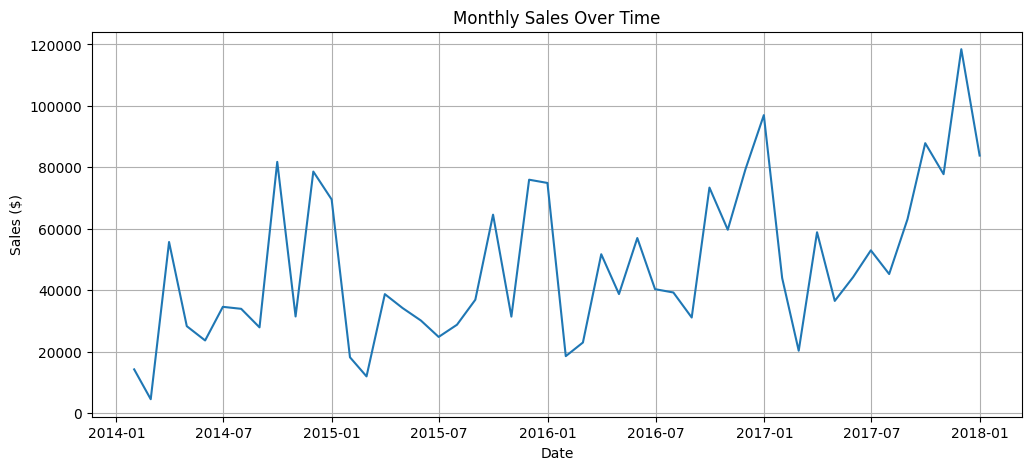

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.show()

In [7]:
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Date', 'Sales']
monthly_sales_df['Month_Number'] = range(1, len(monthly_sales_df) + 1)
monthly_sales_df.head()

,Date,Sales,Month_Number
0,2014-01-31,14236.895,1
1,2014-02-28,4519.892,2
2,2014-03-31,55691.009,3
3,2014-04-30,28295.345,4
4,2014-05-31,23648.287,5


In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = monthly_sales_df[['Month_Number']]
y = monthly_sales_df['Sales']

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [9]:
future_months = np.array(range(len(monthly_sales_df) + 1, len(monthly_sales_df) + 7)).reshape(-1, 1)
future_predictions = model.predict(future_months)

for i, pred in enumerate(future_predictions):
    print(f"Month {len(monthly_sales_df) + i + 1}: Predicted Sales = ${pred:,.2f}")

Month 49: Predicted Sales = $69,957.54
Month 50: Predicted Sales = $70,859.54
Month 51: Predicted Sales = $71,761.55
Month 52: Predicted Sales = $72,663.56
Month 53: Predicted Sales = $73,565.57
Month 54: Predicted Sales = $74,467.57


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


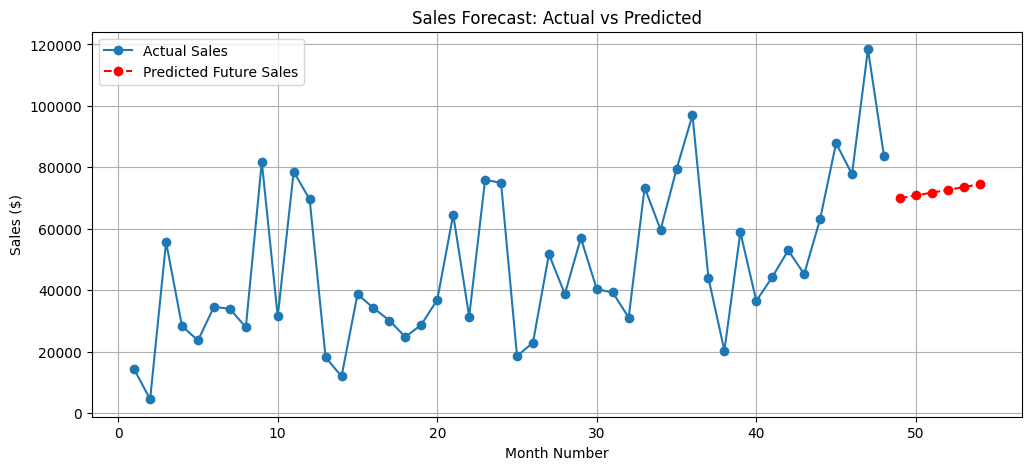

In [10]:
plt.figure(figsize=(12,5))

# Plot actual sales
plt.plot(monthly_sales_df['Month_Number'], monthly_sales_df['Sales'], label='Actual Sales', marker='o')

# Plot predicted future sales
future_month_numbers = range(len(monthly_sales_df) + 1, len(monthly_sales_df) + 7)
plt.plot(future_month_numbers, future_predictions, label='Predicted Future Sales', marker='o', linestyle='--', color='red')

plt.title('Sales Forecast: Actual vs Predicted')
plt.xlabel('Month Number')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on existing data to check accuracy
predicted_existing = model.predict(X)

mae = mean_absolute_error(y, predicted_existing)
rmse = np.sqrt(mean_squared_error(y, predicted_existing))

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Mean Absolute Error (MAE): $17,457.73
Root Mean Squared Error (RMSE): $21,574.53


## Business Summary

This model analyzes 4 years of historical sales data (2014–2018) to forecast sales for the next 6 months.

**Business Context:** This forecast was built for a hypothetical mid-sized retail store selling general merchandise, based on real historical retail transaction patterns from the Superstore dataset.

**Key Findings:**
- Overall sales show a clear upward trend over time, growing from an average of approx. \$30,000/month in 2014 to over \$80,000/month by early 2018.
- The forecast predicts sales will continue growing steadily, reaching approximately \$74,500/month by Month 54.
- The model's average prediction error (MAE) is about \$17,458 per month, meaning forecasts are directionally reliable but should be used alongside human judgment, especially around seasonal peaks.
- **Seasonal pattern identified:** Sales peak sharply in Q4, especially November (approx. \$88,000/month average) and December (approx. \$81,000/month average), likely driven by holiday shopping. February is consistently the slowest month (approx. \$15,000/month average).

**How a Business Can Use This:**
- **Inventory Planning:** Stock up significantly before September–November to prepare for the Q4 sales surge; scale back ordering in January–February when demand drops.
- **Cash Flow Management:** Anticipate a strong revenue quarter in Q4 and plan for leaner cash flow in Q1.
- **Staffing:** Increase staffing from September through December to handle peak demand; reduce hours in the slow Jan–Feb period.

**Limitation:** This model captures the overall growth trend using a simple linear regression but does not fully model month-to-month seasonal fluctuations within its predictions. A more advanced model (e.g., time-series methods like ARIMA or Prophet, or adding seasonal features directly into the regression) could improve short-term forecast accuracy around peak and off-peak periods.

In [12]:
monthly_sales_df['Month_of_Year'] = monthly_sales_df['Date'].dt.month
monthly_sales_df.head()

,Date,Sales,Month_Number,Month_of_Year
0,2014-01-31,14236.895,1,1
1,2014-02-28,4519.892,2,2
2,2014-03-31,55691.009,3,3
3,2014-04-30,28295.345,4,4
4,2014-05-31,23648.287,5,5


In [13]:
seasonal_avg = monthly_sales_df.groupby('Month_of_Year')['Sales'].mean()
print(seasonal_avg)

Month_of_Year
1     23731.208900
2     14937.812850
3     51251.372200
4     34440.532150
5     38757.202925
6     38179.669825
7     36809.524250
8     39761.015750
9     76912.486425
10    50080.746175
11    88115.267750
12    81323.375875
Name: Sales, dtype: float64
